# Pra-Pemrosesan dan Pelabelan Niat Pelanggan Service Komputer

In [39]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Mengatur palet warna monokrom untuk estetika pencetakan akademis
sns.set_palette(['#333333', '#777777', '#cccccc'])

df_mentah = pd.read_csv('data/master_chat_wa.csv')
print("=== METADATA DATA UTAMA ===")
df_mentah.info()
print("\n=== SAMPEL DATA UTAMA ===")
display(df_mentah.head(3))

=== METADATA DATA UTAMA ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3502 entries, 0 to 3501
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Country         3502 non-null   object
 1   Phone Number    3502 non-null   int64 
 2   Formatted Name  3502 non-null   object
 3   Display Name    3418 non-null   object
 4   Message Time    3502 non-null   object
 5   Message Type    3502 non-null   object
 6   Message Body    3447 non-null   object
 7   Message Id      3502 non-null   object
dtypes: int64(1), object(7)
memory usage: 219.0+ KB

=== SAMPEL DATA UTAMA ===


,Country,Phone Number,Formatted Name,Display Name,Message Time,Message Type,Message Body,Message Id
0,Indonesia,6285752887496,Anda,anugerahcomputer4,2026-04-27 12:10:50,chat,【IMAGE】,true_211622366855206@lid_AC2292D9378555369E125...
1,Indonesia,6285752887496,Anda,anugerahcomputer4,2026-04-27 12:10:55,chat,Anugerah komputer,true_211622366855206@lid_ACEC981E86F9304411889...
2,Indonesia,6281156701235,+62 811-5670-1235,NaN,2026-04-27 16:13:57,chat,Oke bg,false_211622366855206@lid_ACCC7B568284EA7BDECA...


## Ekstraksi Fitur Dasar
Memecah atribut `Message Id` untuk mengidentifikasi siapa pengirim pesan (Admin atau Pelanggan) dan ID Obrolan (`Chat_ID`) untuk merekonstruksi riwayat percakapan.

In [40]:
# 1. Konversi Teks menjadi Objek Waktu agar dapat dihitung secara matematis
df_mentah['Message Time'] = pd.to_datetime(df_mentah['Message Time'], errors='coerce')

# 2. Menghapus baris anomali yang waktu pesannya gagal dikonversi
df_mentah = df_mentah.dropna(subset=['Message Time']).copy()

# 3. Ekstraksi Fitur 1: is_admin (True jika pesan dari admin, False jika dari pelanggan)
df_mentah['is_admin'] = df_mentah['Message Id'].astype(str).str.startswith('true_')

# 4. Ekstraksi Fitur 2: Chat_ID (Mengambil string di antara 'true_'/'false_' dan '@')
df_mentah['Chat_ID'] = df_mentah['Message Id'].astype(str).apply(lambda x: x.split('_')[1].split('@')[0] if len(x.split('_')) > 1 else 'unknown')

print("=== HASIL EKSTRAKSI FITUR DASAR ===")
display(df_mentah[['Message Time', 'is_admin', 'Chat_ID', 'Message Body']].head())

=== HASIL EKSTRAKSI FITUR DASAR ===


,Message Time,is_admin,Chat_ID,Message Body
0,2026-04-27 12:10:50,True,211622366855206,【IMAGE】
1,2026-04-27 12:10:55,True,211622366855206,Anugerah komputer
2,2026-04-27 16:13:57,False,211622366855206,Oke bg
3,2026-04-29 10:17:27,False,211622366855206,Bg berapa kemarin harganya ya
4,2026-04-29 10:18:06,True,211622366855206,Nnti tnya y bg blom dtg bos nya


## Cek Keterlambatan Waktu Respons
Menghitung selisih waktu antara pesan pelanggan masuk dan balasan dari admin dalam satu obrolan untuk memvalidasi masalah operasional toko.

In [41]:
# MENGAMBIL OBROLAN (CHAT ID)
print("=== Melihat obrolan ===")
contoh_kamar = df_mentah['Chat_ID'].dropna().unique()[145]
bukti_percakapan = df_mentah[df_mentah['Chat_ID'] == contoh_kamar].sort_values('Message Time')

for idx, row in bukti_percakapan.iterrows():
    waktu = row['Message Time'].strftime('%Y-%m-%d %H:%M:%S')
    pengirim = "ADMIN" if row['is_admin'] else "PELANGGAN"
    pesan = row['Message Body']
    print(f"[{waktu}] {pengirim}: {pesan}")

=== Melihat obrolan ===
[2025-10-20 14:11:31] ADMIN: Selamat pagi bang. Laptop Advan nya udh kami cek bang, mic internal nya gak berfungsi kak
[2025-10-20 15:10:31] ADMIN: Untuk perbaikannya kena Rp200.000 bang
[2025-10-20 15:31:31] PELANGGAN: Bisa kurang gak bang?
[2025-10-20 16:15:31] ADMIN: Udah pas segitu bang, itu udh termasuk part + jasa
[2025-10-20 16:54:31] PELANGGAN: Nanti aja perbaikanya bang
[2025-10-20 17:01:31] ADMIN: Ok bang dimengerti


In [42]:
# Mengurutkan percakapan berdasarkan ruang obrolan dan waktu
df_mentah = df_mentah.sort_values(by=['Chat_ID', 'Message Time']).reset_index(drop=True)

response_times = []
unreplied = 0
total_inquiries = 0

# Iterasi untuk mensimulasikan penghitungan waktu tunggu
for chat_id, group in df_mentah.groupby('Chat_ID'):
    group = group.sort_values('Message Time').reset_index(drop=True)
    waiting = False
    inq_time = None
    
    for _, row in group.iterrows():
        if not row['is_admin']:
            if not waiting:
                waiting = True
                inq_time = row['Message Time']
                total_inquiries += 1
        else:
            if waiting:
                delay_minutes = (row['Message Time'] - inq_time).total_seconds() / 60.0
                response_times.append(delay_minutes)
                waiting = False
                
    if waiting:
        unreplied += 1

print(f"Total Sesi Inisiasi Pelanggan: {total_inquiries}")
print(f"Sesi Diabaikan Admin: {unreplied}")
print(f"Rata-Rata Tunggu (Bagi yang Dibalas): {np.mean(response_times):.2f} Menit")

Total Sesi Inisiasi Pelanggan: 1171
Sesi Diabaikan Admin: 198
Rata-Rata Tunggu (Bagi yang Dibalas): 631.79 Menit


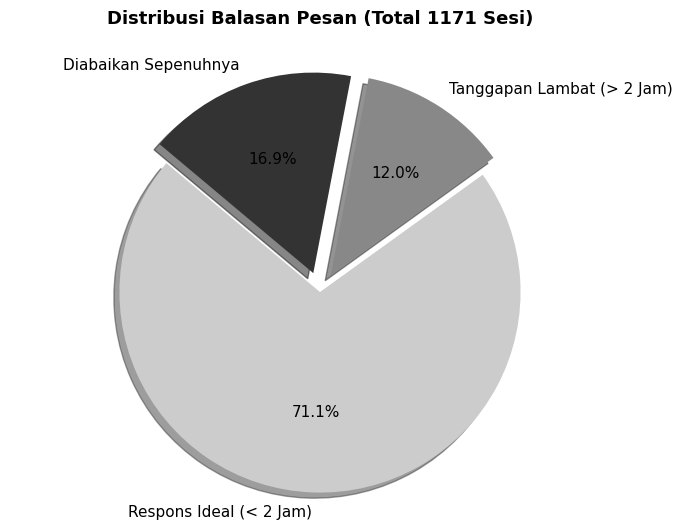

In [43]:
# Klasifikasi keterlambatan
lambat = sum(1 for x in response_times if x > 120)
normal = total_inquiries - unreplied - lambat

labels = ['Respons Ideal (< 2 Jam)', 'Tanggapan Lambat (> 2 Jam)', 'Diabaikan Sepenuhnya']
sizes = [normal, lambat, unreplied]
colors = ['#cccccc', '#888888', '#333333']
explode = (0, 0.1, 0.1)

plt.figure(figsize=(8, 6))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', 
        shadow=True, startangle=140, textprops={'fontsize': 11, 'color': 'black'})
plt.title(f'Distribusi Balasan Pesan (Total {total_inquiries} Sesi)', fontsize=13, fontweight='bold', pad=20)
plt.axis('equal')
plt.show()

## Pembersihan (*Noise Reduction*) & Normalisasi Dasar
Membersihkan lampiran gambar otomatis, pesan kosong, dan melakukan *Case Folding* (huruf kecil).

In [44]:
# 1. Menghapus pesan otomatis WA berupa lampiran gambar 【IMAGE】
df_bersih = df_mentah[~df_mentah['Message Body'].astype(str).str.contains(r'【.*?】', regex=True)].copy()

# 2. Menghapus baris yang teksnya kosong atau NaN
df_bersih = df_bersih.dropna(subset=['Message Body']).copy()
df_bersih = df_bersih[df_bersih['Message Body'].astype(str).str.strip() != '']

# 3. Case Folding (Ubah ke huruf kecil semua)
df_bersih['text_lower'] = df_bersih['Message Body'].astype(str).str.lower()

print(f"Sisa Data Setelah Noise Reduction: {len(df_bersih)} baris")

Sisa Data Setelah Noise Reduction: 3078 baris


## Identifikasi Aktor & Standarisasi Teks
Mengekstrak pesan khusus dari pelanggan saja, dan mendefinisikan fungsi standarisasi tanda baca (`text_normalization`) yang akan digunakan sepanjang riset.

In [45]:
# Menyaring tabel HANYA untuk pesan pelanggan
df_pelanggan = df_bersih[df_bersih['is_admin'] == False].copy()

# Definisi Fungsi Standarisasi Akademis
def text_normalization(text):
    if not isinstance(text, str): return ""
    text = text.lower() # Huruf kecil
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Hapus Tautan
    text = re.sub(r'[^a-z\s]', '', text) # Hapus tanda baca
    text = re.sub(r'\s+', ' ', text).strip() # Rapikan spasi berlebih
    return text

# Terapkan standarisasi pada teks pelanggan
df_pelanggan['clean_text'] = df_pelanggan['text_lower'].apply(text_normalization)

print(f"Total Pesan Murni Pelanggan: {len(df_pelanggan)} baris")
print("\n=== 5 PESAN TERBANYAK (MURNI PELANGGAN) ===")
print(df_pelanggan['clean_text'].value_counts().head(5))

Total Pesan Murni Pelanggan: 1581 baris

=== 5 PESAN TERBANYAK (MURNI PELANGGAN) ===
clean_text
ok          29
oke bang    29
oke bg      14
            13
ok bg       11
Name: count, dtype: int64


## Pra-Pelabelan
Implementasi algoritma pencocokan kata kunci berdasarkan observasi *Ground Truth* awal untuk menyuntikkan label otomatis (setuju, batal, lainnya).

=== HASIL PRA-PELABELAN OTOMATIS ===
intent
lainnya    839
setuju     702
batal       40
Name: count, dtype: int64


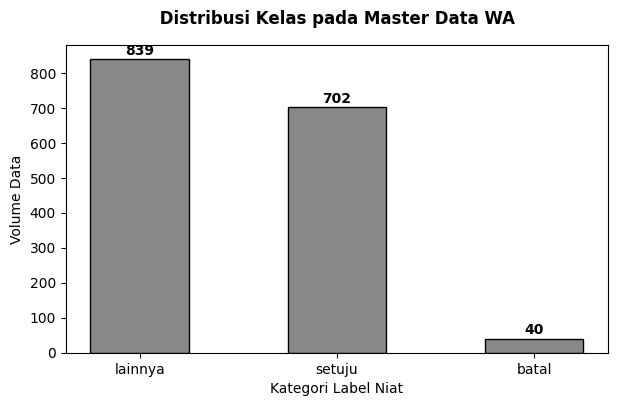

In [46]:
def rule_based_labeler(text):
    # Kata kunci khas dialek dan kebiasaan membalas
    kunci_batal = ['batal', 'tak usah', 'btl', 'cancel', 'kemahalan', 'mahal', 'ndak jadi', 'skip', 'ambil aja', 'ambil yak', 'nanti dolok']
    kunci_setuju = ['lanjut', 'setuju', 'sikat', 'oke', 'boleh', 'iyak', 'ganti', 'kerjakan', 'gas', 'baik', 'ok', 'iya', 'okey']
    
    if any(word in text for word in kunci_batal):
        return 'batal'
    elif any(word in text for word in kunci_setuju):
        return 'setuju'
    else:
        return 'lainnya'

df_pelanggan['intent'] = df_pelanggan['clean_text'].apply(rule_based_labeler)

distribusi_awal = df_pelanggan['intent'].value_counts()
print("=== HASIL PRA-PELABELAN OTOMATIS ===")
print(distribusi_awal)

# Visualisasi Ketimpangan Kelas
plt.figure(figsize=(7, 4))
bars = plt.bar(distribusi_awal.index, distribusi_awal.values, color='#888888', edgecolor='black', width=0.5)
plt.title(' Distribusi Kelas pada Master Data WA ', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Kategori Label Niat')
plt.ylabel('Volume Data')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval), ha='center', va='bottom', fontweight='bold')
plt.show()

In [47]:
# Mengekspor hasil pra-pelabelan mesin untuk divalidasi
df_pelanggan.to_csv('data/hasil_prapelabelan_mesin.csv', index=False)
print("File CSV berhasil diekspor! ...")

File CSV berhasil diekspor! ...


=== SAMPEL DATA MASTER TERVALIDASI PAKAR ===


,clean_text,intent
1124,besok buka jamber,lainnya
813,tak bisa kurang lg k,setuju
1175,diskon dikit boleh bg,lainnya
534,baik bang,setuju
514,buka sampe jam berapa bg,lainnya



=== DISTRIBUSI LABEL (TERVALIDASI PAKAR) ===
intent
lainnya    878
setuju     661
batal       42
Name: count, dtype: int64


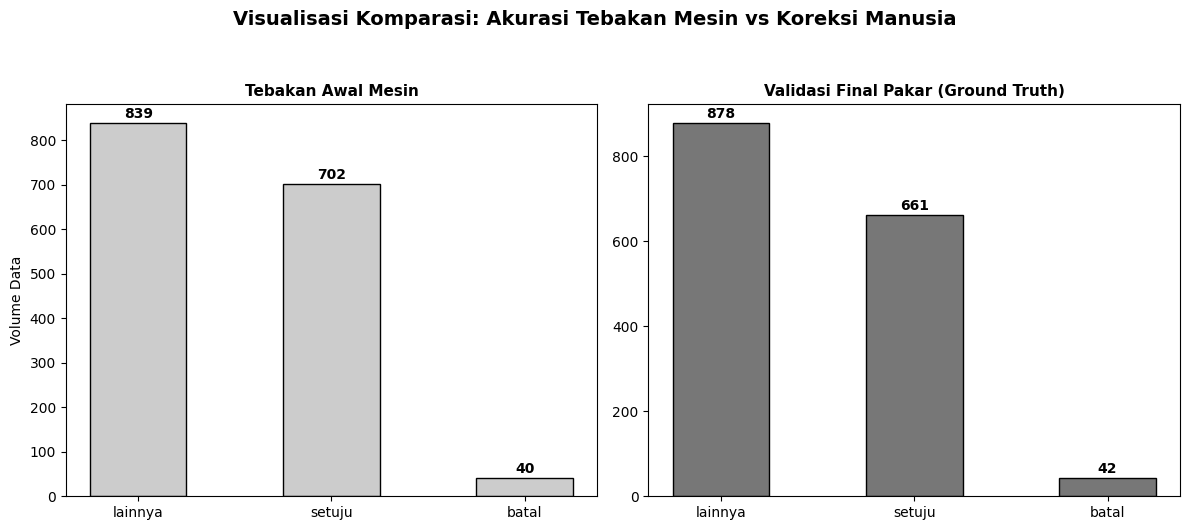

In [48]:
# 1. Memuat data Master Chat yang sudah divalidasi pakar
df_validasi = pd.read_csv('data/master_chat_tervalidasi.csv')

print("=== SAMPEL DATA MASTER TERVALIDASI PAKAR ===")
display(df_validasi[['clean_text', 'intent']].sample(5, random_state=42))

# 2. Menghitung distribusi niat hasil validasi pakar
distribusi_validasi = df_validasi['intent'].value_counts()
print("\n=== DISTRIBUSI LABEL (TERVALIDASI PAKAR) ===")
print(distribusi_validasi)

# 3. Visualisasi Komparasi (Mesin vs Pakar)
# Catatan: Jika Anda tidak merubah label apapun di CSV secara manual, grafiknya akan terlihat identik.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Chart Kiri: Tebakan Mesin (Variabel 'distribusi_awal' dari BAB VI)
axes[0].bar(distribusi_awal.index, distribusi_awal.values, color='#cccccc', edgecolor='black', width=0.5)
axes[0].set_title('Tebakan Awal Mesin', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Volume Data')
for bar in axes[0].patches:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, int(bar.get_height()), ha='center', va='bottom', fontweight='bold')

# Chart Kanan: Validasi Final Pakar
axes[1].bar(distribusi_validasi.index, distribusi_validasi.values, color='#777777', edgecolor='black', width=0.5)
axes[1].set_title('Validasi Final Pakar (Ground Truth)', fontsize=11, fontweight='bold')
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, int(bar.get_height()), ha='center', va='bottom', fontweight='bold')

plt.suptitle('Visualisasi Komparasi: Akurasi Tebakan Mesin vs Koreksi Manusia', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()


## BAB VII: Konsolidasi Ekosistem WhatsApp Final
Data suplemen dari ekstraksi pakar (`data_baru_dari_wa_clean.csv`) digabungkan dengan `df_pelanggan` untuk menciptakan ekosistem obrolan WhatsApp yang tervalidasi secara utuh.

=== EKSPOR BERHASIL: dataset_wa_final.csv ===
Total Baris Ekosistem WA Tervalidasi: 1365 Baris



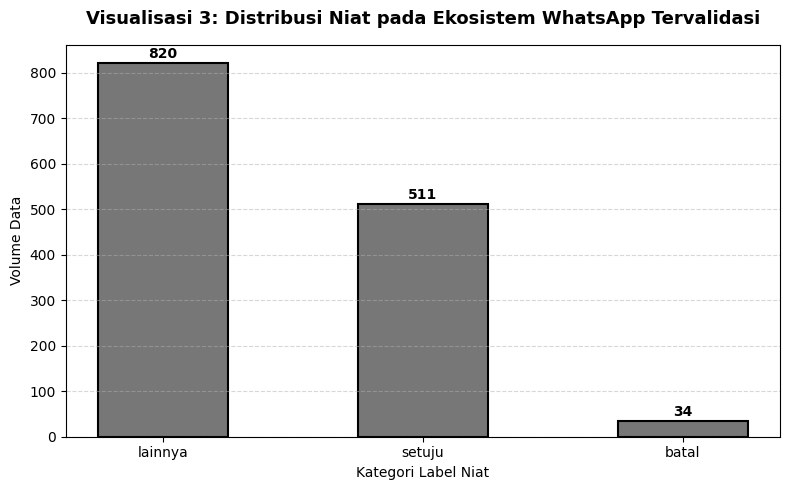

In [49]:
# 1. Memuat data suplemen WA
df_wa_suplemen = pd.read_csv('data/data_baru_dari_wa_clean.csv')

# 2. Standarisasi Teks Data Suplemen
df_wa_suplemen['clean_text'] = df_wa_suplemen['text'].apply(text_normalization)
df_wa_suplemen['intent'] = df_wa_suplemen['intent'].astype(str).str.lower().str.strip()

# 3. MENGAMBIL 4 KOLOM EMAS & MENYUNTIKKAN SUMBER (SOURCE)
# Untuk master chat (kita ubah nama 'Message Body' menjadi 'text' agar seragam)
df_wa_utama = df_validasi[['Message Body', 'clean_text', 'intent']].copy()
df_wa_utama = df_wa_utama.rename(columns={'Message Body': 'text'})
df_wa_utama['source'] = 'master_chat'

# Untuk data suplemen
df_wa_suplemen_bersih = df_wa_suplemen[['text', 'clean_text', 'intent']].copy()
df_wa_suplemen_bersih['source'] = 'suplemen_wa'

# 4. Peleburan (Concatenation) & Hapus Duplikasi
df_wa_final = pd.concat([df_wa_utama, df_wa_suplemen_bersih], ignore_index=True)
df_wa_final = df_wa_final.drop_duplicates(subset=['clean_text', 'intent'])
df_wa_final = df_wa_final[df_wa_final['clean_text'] != ''] # Hapus string kosong

# 5. EKSPOR KE CSV FINAL WA
df_wa_final.to_csv('data/dataset_wa_final.csv', index=False)
print("=== EKSPOR BERHASIL: dataset_wa_final.csv ===")

distribusi_wa_final = df_wa_final['intent'].value_counts()
print(f"Total Baris Ekosistem WA Tervalidasi: {len(df_wa_final)} Baris\n")

# Visualisasi Ekosistem WA
plt.figure(figsize=(8, 5))
bars = plt.bar(distribusi_wa_final.index, distribusi_wa_final.values, color='#777777', edgecolor='black', linewidth=1.5, width=0.5)
plt.title('Visualisasi 3: Distribusi Niat pada Ekosistem WhatsApp Tervalidasi', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Kategori Label Niat')
plt.ylabel('Volume Data')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval), ha='center', va='bottom', fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## BAB VIII: Integrasi Data Primer (Kuesioner Dialek)
Data hasil penyebaran kuesioner memiliki struktur *Wide-Format* (horizontal) di mana satu responden mengisi enam skenario jawaban. Agar dapat dilatih oleh model *Machine Learning*, data ini harus dikonversi menjadi *Long-Format* (vertikal) melalui proses *Data Melting*. Selanjutnya, data ini akan distandarisasi menggunakan fungsi `text_normalization` yang sama dengan ekosistem WhatsApp demi menjaga konsistensi matriks fitur teks.


In [50]:
# 1. Memuat file raw kuesioner
path_kuesioner = 'data/Pengumpulan_Data_Linguistik_Interaksi_Layanan_Pelanggan_untuk_Pelatihan_Model_Natural_Language_Processing_(NLP)_(Jawaban).csv'
df_raw_kuesioner = pd.read_csv(path_kuesioner)

print("=== BENTUK ASLI DATA KUESIONER (WIDE FORMAT) ===")
# Tampilkan 3 baris saja sudah cukup untuk melihat betapa panjangnya data menyamping
display(df_raw_kuesioner.head(3))


=== BENTUK ASLI DATA KUESIONER (WIDE FORMAT) ===


,Timestamp,1. Rentang Usia:,2. Tingkat pemahaman dan penggunaan dialek Melayu Pontianak dalam komunikasi pesan teks:,1. Tuliskan balasan singkat secara natural jika penawaran biaya tersebut disetujui.,2. Tuliskan balasan persetujuan dengan menggunakan dialek Melayu Pontianak secara kental...,3. Tuliskan balasan singkat secara natural jika biaya ditolak dan unit ingin diambil kembali.,4. Tuliskan balasan pembatalan perbaikan dengan menggunakan dialek Melayu Pontianak...,5. Tuliskan balasan yang secara spesifik memuat negosiasi atau tawar-menawar harga perbaikan.,6. Tuliskan balasan yang mempertanyakan durasi atau estimasi waktu pengerjaan...
0,14/08/2026 9:09:00,>35 Tahun,Aktif (Sering menggunakan),okeh,"Sikat jak bang, tpi saye nak nunggu disitok bi...",Batal jak bang,"Tunda lok pak, nnti mun ade rezeki saye balek ...",Hargenye bise turun sikit ndak min?,Bang mun nak betolkan laptop kire-kire sampai ...
1,14/08/2026 9:13:00,18 - 25 Tahun,Aktif (Sering menggunakan),boleh kak,"Sikat jak bang, tpi saye nak nunggu disitok bi...",gk jd,"Aduh duit saye tak cukop bg, ambek lok lah nnti",Nda bise kurang hargenye tu bang?,Kak lokasi pastinya di belah mane ye?
2,14/08/2026 9:53:00,>35 Tahun,Aktif (Sering menggunakan),Lanjut pak,"Gass bah min, cepatkan sikit ye soale saye nak...",Batal,nd usah bang. agek butuh makai banyak duet,Nd bise kurang ke bang hargenye tu?,Bg nnti malam bukak ndak?


In [51]:
# Kita ambil HANYA nama-nama kolom yang berisi teks jawaban (indeks ke-3 sampai batas ke-9)
kolom_teks = df_raw_kuesioner.columns[3:9]

print("=== 6 KOLOM PERTANYAAN YANG AKAN DILELEHKAN ===")
for i, col in enumerate(kolom_teks):
    print(f"{i+1}. {col}")


=== 6 KOLOM PERTANYAAN YANG AKAN DILELEHKAN ===
1. 1. Tuliskan balasan singkat secara natural jika penawaran biaya tersebut disetujui.
2. 2. Tuliskan balasan persetujuan dengan menggunakan dialek Melayu Pontianak secara kental...
3. 3. Tuliskan balasan singkat secara natural jika biaya ditolak dan unit ingin diambil kembali.
4. 4. Tuliskan balasan pembatalan perbaikan dengan menggunakan dialek Melayu Pontianak...
5. 5. Tuliskan balasan yang secara spesifik memuat negosiasi atau tawar-menawar harga perbaikan.
6. 6. Tuliskan balasan yang mempertanyakan durasi atau estimasi waktu pengerjaan...


In [52]:
# Fungsi 'melt' meruntuhkan 6 kolom menyamping menjadi format vertikal
df_kuesioner_melted = df_raw_kuesioner.melt(
    id_vars=[], 
    value_vars=kolom_teks, 
    var_name='pertanyaan', 
    value_name='text'
)

print("=== HASIL SETELAH DILELEHKAN (LONG FORMAT) ===")
# Jumlah baris seharusnya menjadi 103 responden x 6 pertanyaan = 618 baris
print(f"Jumlah baris sekarang: {len(df_kuesioner_melted)}")
display(df_kuesioner_melted.head(5))


=== HASIL SETELAH DILELEHKAN (LONG FORMAT) ===
Jumlah baris sekarang: 618


,pertanyaan,text
0,1. Tuliskan balasan singkat secara natural jik...,okeh
1,1. Tuliskan balasan singkat secara natural jik...,boleh kak
2,1. Tuliskan balasan singkat secara natural jik...,Lanjut pak
3,1. Tuliskan balasan singkat secara natural jik...,lanjut bg
4,1. Tuliskan balasan singkat secara natural jik...,Boleh bg


In [53]:
# Membuat kamus pemetaan manual berdasarkan urutan 6 kolom pertanyaan tadi
mapping_intent = {
    kolom_teks[0]: 'setuju',
    kolom_teks[1]: 'setuju',
    kolom_teks[2]: 'batal',
    kolom_teks[3]: 'batal',
    kolom_teks[4]: 'lainnya',
    kolom_teks[5]: 'lainnya'
}

# 1. Suntik label dengan cara menerjemahkan kolom 'pertanyaan'
df_kuesioner_melted['intent'] = df_kuesioner_melted['pertanyaan'].map(mapping_intent)

# 2. Membersihkan data yang kosong (jika ada responden yang tidak mengisi)
df_kuesioner_melted = df_kuesioner_melted.dropna(subset=['text']).copy()

# 3. Terapkan Standarisasi (rumus andalan kita)
df_kuesioner_melted['clean_text'] = df_kuesioner_melted['text'].apply(text_normalization)

# 4. Suntik sumber data
df_kuesioner_melted['source'] = 'kuesioner'

# 5. Bungkus dan ambil 4 Kolom Emas
df_kuesioner_final = df_kuesioner_melted[['text', 'clean_text', 'intent', 'source']].copy()

print("=== HASIL AKHIR EKSTRAKSI DATA KUESIONER ===")
display(df_kuesioner_final.sample(5, random_state=42))


=== HASIL AKHIR EKSTRAKSI DATA KUESIONER ===


,text,clean_text,intent,source
49,Sip,sip,setuju,kuesioner
582,Kak lokasi pastinya di belah mane ye?,kak lokasi pastinya di belah mane ye,lainnya,kuesioner
82,Okey,okey,setuju,kuesioner
305,cancell ajaa min,cancell ajaa min,batal,kuesioner
109,"Aok min, kerjekan jak lok. Tpi jangan diinstal...",aok min kerjekan jak lok tpi jangan diinstal u...,setuju,kuesioner


=== DISTRIBUSI LABEL KUESIONER ===
intent
setuju     206
batal      206
lainnya    206
Name: count, dtype: int64


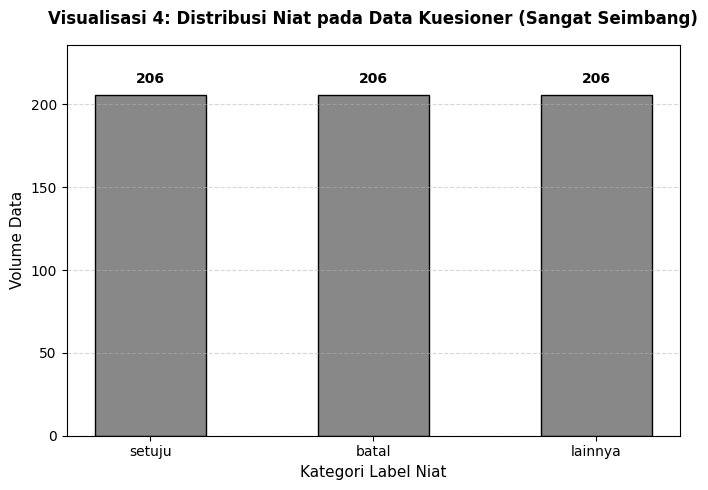

In [54]:
# Menghitung distribusi niat pada data kuesioner
distribusi_kuesioner = df_kuesioner_final['intent'].value_counts()

print("=== DISTRIBUSI LABEL KUESIONER ===")
print(distribusi_kuesioner)

# Membuat Bar Chart Monokrom
plt.figure(figsize=(7, 5))
bars = plt.bar(distribusi_kuesioner.index, distribusi_kuesioner.values, color='#888888', edgecolor='black', width=0.5)

plt.title('Visualisasi 4: Distribusi Niat pada Data Kuesioner (Sangat Seimbang)', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Kategori Label Niat', fontsize=11)
plt.ylabel('Volume Data', fontsize=11)
plt.ylim(0, max(distribusi_kuesioner.values) + 30) # Memberi ruang agar angka tidak menabrak atap grafik

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval), ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## BAB IX: Fusi Ekosistem WA dan Kuesioner (Dataset Siap Latih)
Tahap prapemrosesan diakhiri dengan menggabungkan dataset historis WhatsApp yang mencerminkan interaksi natural, dengan dataset Kuesioner yang memperkaya ragam dialek dan mengangkat volume kelas minoritas. Dataset gabungan ini diekspor menjadi matriks akhir yang siap dilatih oleh algoritma NLP.


=== EKSPOR BERHASIL: dataset_siap_latih_final.csv ===

=== DISTRIBUSI LABEL FINAL (SIAP LATIH) ===
intent
lainnya    884
setuju     570
batal       92
Name: count, dtype: int64


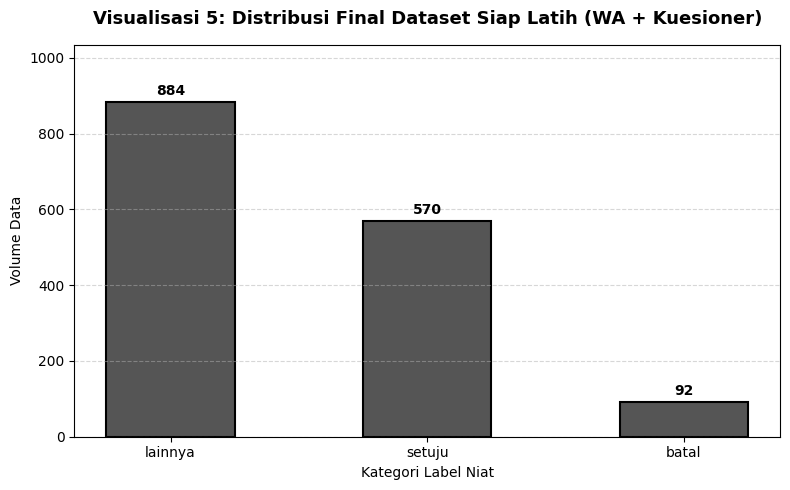

In [55]:
# 1. Memuat kembali data WA Final (Titik Aman Sebelumnya)
df_wa_final = pd.read_csv('data/dataset_wa_final.csv')

# 2. Penggabungan (Concatenation) WA dan Kuesioner
df_siap_latih = pd.concat([df_wa_final, df_kuesioner_final], ignore_index=True)

# 3. Menghapus duplikasi silang (barangkali ada kalimat kuesioner yang persis sama dengan WA)
df_siap_latih = df_siap_latih.drop_duplicates(subset=['clean_text', 'intent']).copy()

# 4. EKSPOR KE CSV FINAL (DATASET SIAP LATIH)
df_siap_latih.to_csv('data/dataset_siap_latih_final.csv', index=False)
print("=== EKSPOR BERHASIL: dataset_siap_latih_final.csv ===")

# 5. Visualisasi Distribusi Final (Untuk Menentukan Tindakan di Tahap Training)
distribusi_siap_latih = df_siap_latih['intent'].value_counts()
print("\n=== DISTRIBUSI LABEL FINAL (SIAP LATIH) ===")
print(distribusi_siap_latih)

plt.figure(figsize=(8, 5))
bars = plt.bar(distribusi_siap_latih.index, distribusi_siap_latih.values, color='#555555', edgecolor='black', linewidth=1.5, width=0.5)

plt.title('Visualisasi 5: Distribusi Final Dataset Siap Latih (WA + Kuesioner)', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Kategori Label Niat')
plt.ylabel('Volume Data')
plt.ylim(0, max(distribusi_siap_latih.values) + 150) # Ruang ekstra

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 10, int(yval), ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
